In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import numpy as np
import re
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
import time
from sklearn.preprocessing import MinMaxScaler

from sklearn.feature_selection import mutual_info_regression

# Atur agar semua kolom terlihat
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_seq_items', None)
pd.options.display.max_rows = None
pd.options.display.max_columns = None

# df = pd.read_csv('AB_US_2023.csv')
# dt = pd.read_csv('AB_US_2020.csv')

In [41]:
df = pd.read_csv("airbnb-listings-us-cleaned-o (1).csv", low_memory=False)

In [42]:
df.drop(["Amenities", "Last Scraped", "Calendar Updated", "Calendar last Scraped"], axis=1, inplace=True)

In [4]:
df.head()

,Host Since,Host Response Time,Host Response Rate,Host Neighbourhood,Host Total Listings Count,Neighbourhood,City,State,Zipcode,Latitude,Longitude,Property Type,Room Type,Accommodates,Bathrooms,Bedrooms,Beds,Bed Type,Price,Cleaning Fee,Guests Included,Extra People,Minimum Nights,Maximum Nights,Availability 30,Availability 60,Availability 90,Availability 365,Number of Reviews,Review Scores Rating,Review Scores Accuracy,Review Scores Cleanliness,Review Scores Checkin,Review Scores Communication,Review Scores Location,Review Scores Value,Cancellation Policy,Calculated host listings count,Reviews per Month,Wireless Internet,Heating,Kitchen,Essentials,TV,Smoke detector,Shampoo,Internet,Washer,Dryer
0,2014-11-22 00:00:00,within an hour,100.0,Woodland Hills/Warner Center,1,Woodland Hills,Los Angeles,CA,91364,34.147756,-118.591338,Apartment,Private room,2.0,1,1,1,Real Bed,150.0,25.0,1.0,0.0,1.0,1125.0,30.0,60.0,90.0,365.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,flexible,1.0,0.00,True,True,False,True,True,True,True,True,False,False
1,2016-02-02 00:00:00,within a day,100.0,Woodland Hills/Warner Center,1,Woodland Hills,Los Angeles,CA,91364,34.164597,-118.600512,House,Entire home/apt,8.0,3,4,4,Real Bed,175.0,150.0,8.0,25.0,2.0,1125.0,9.0,19.0,28.0,28.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,flexible,1.0,0.00,True,True,True,True,True,True,True,True,True,True
2,2016-11-22 00:00:00,within a few hours,100.0,Woodland Hills/Warner Center,1,Woodland Hills,Los Angeles,CA,91367,34.183150,-118.645064,Guesthouse,Entire home/apt,3.0,1,1,1,Real Bed,79.0,55.0,1.0,25.0,2.0,26.0,30.0,60.0,90.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,flexible,1.0,0.00,True,True,True,True,True,True,False,True,True,True
3,2011-04-13 00:00:00,within a few hours,100.0,Woodland Hills/Warner Center,2,Woodland Hills,Woodland Hills,CA,91364,34.148594,-118.596684,Other,Entire home/apt,2.0,1,1,1,Real Bed,175.0,100.0,1.0,0.0,2.0,5.0,12.0,42.0,72.0,72.0,2.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,strict,2.0,0.16,True,True,True,True,True,True,True,True,True,True
4,2015-01-03 00:00:00,within an hour,100.0,Studio City,36,Woodland Hills,Los Angeles,CA,91367,34.174245,-118.605876,Townhouse,Entire home/apt,6.0,2,3,4,Real Bed,450.0,200.0,6.0,50.0,3.0,1125.0,26.0,56.0,86.0,361.0,8.0,95.0,9.0,10.0,10.0,10.0,9.0,10.0,moderate,29.0,0.79,True,True,True,True,True,True,False,True,True,True


In [262]:
df.isnull().sum() / len(df) * 100

Host Since                        0.0
Host Response Time                0.0
Host Response Rate                0.0
Host Neighbourhood                0.0
Host Total Listings Count         0.0
Neighbourhood                     0.0
City                              0.0
State                             0.0
Zipcode                           0.0
Latitude                          0.0
Longitude                         0.0
Property Type                     0.0
Room Type                         0.0
Accommodates                      0.0
Bathrooms                         0.0
Bedrooms                          0.0
Beds                              0.0
Bed Type                          0.0
Price                             0.0
Cleaning Fee                      0.0
Guests Included                   0.0
Extra People                      0.0
Minimum Nights                    0.0
Maximum Nights                    0.0
Availability 30                   0.0
Availability 60                   0.0
Availability

## Encoding feature ordinal

In [43]:
ordinal_mapping = {
    "within an hour": 0,
    "within a few hours": 1,
    "within a day": 2,
    "a few days or more": 3
}

# Lakukan encoding di Train Set (X_train)
df['Host Response Time'] = df['Host Response Time'].map(ordinal_mapping)



print(df['Host Response Time'].unique()) 


[0 2 1 3]


## Encoding features One-Hot

In [44]:
# One-Hot Encoding (Hanya di Train)
df = pd.get_dummies(df, columns=['Room Type', 'Bed Type', 'Cancellation Policy'], drop_first=True)



print("df:", df.head())


df:             Host Since  Host Response Time  Host Response Rate  \
0  2014-11-22 00:00:00                   0               100.0   
1  2016-02-02 00:00:00                   2               100.0   
2  2016-11-22 00:00:00                   1               100.0   
3  2011-04-13 00:00:00                   1               100.0   
4  2015-01-03 00:00:00                   0               100.0   

             Host Neighbourhood  Host Total Listings Count   Neighbourhood  \
0  Woodland Hills/Warner Center                          1  Woodland Hills   
1  Woodland Hills/Warner Center                          1  Woodland Hills   
2  Woodland Hills/Warner Center                          1  Woodland Hills   
3  Woodland Hills/Warner Center                          2  Woodland Hills   
4                   Studio City                         36  Woodland Hills   

             City State  Zipcode   Latitude   Longitude Property Type  \
0     Los Angeles    CA    91364  34.147756 -118.591338  

In [45]:
for col in df.select_dtypes(include=['bool']).columns:
   df[col] = df[col].astype(int)

for col in df.select_dtypes(include=['bool']).columns:
    df[col] = df[col].astype(int)


print(df.dtypes)  


Host Since                              object
Host Response Time                       int64
Host Response Rate                     float64
Host Neighbourhood                      object
Host Total Listings Count                int64
Neighbourhood                           object
City                                    object
State                                   object
Zipcode                                  int64
Latitude                               float64
Longitude                              float64
Property Type                           object
Accommodates                           float64
Bathrooms                                int64
Bedrooms                                 int64
Beds                                     int64
Price                                  float64
Cleaning Fee                           float64
Guests Included                        float64
Extra People                           float64
Minimum Nights                         float64
Maximum Night

In [8]:
df.isnull().sum() / len(df) * 100

Host Since                             0.0
Host Response Time                     0.0
Host Response Rate                     0.0
Host Neighbourhood                     0.0
Host Total Listings Count              0.0
Neighbourhood                          0.0
City                                   0.0
State                                  0.0
Zipcode                                0.0
Latitude                               0.0
Longitude                              0.0
Property Type                          0.0
Accommodates                           0.0
Bathrooms                              0.0
Bedrooms                               0.0
Beds                                   0.0
Price                                  0.0
Cleaning Fee                           0.0
Guests Included                        0.0
Extra People                           0.0
Minimum Nights                         0.0
Maximum Nights                         0.0
Availability 30                        0.0
Availabilit

## Convert datetime

In [46]:
# ⿡ Bersihkan nilai kosong atau tidak valid
df["Host Since"] = df["Host Since"].replace(["", " ", "NaN", "nan", "None", "not available"], pd.NA)

# ⿢ Simpan nilai asli sebelum konversi pertama
df["Host Since Raw"] = df["Host Since"]

# ⿣ Coba konversi ke datetime dengan format tanpa jam (YYYY-MM-DD)
df["Host Since"] = pd.to_datetime(df["Host Since"], format="%Y-%m-%d", errors="coerce")

# ⿤ Cari data yang masih NaT setelah konversi pertama
mask_nat = df["Host Since"].isna()

# ⿥ Konversi ulang hanya untuk data yang masih NaT menggunakan Host Since Raw
df.loc[mask_nat, "Host Since"] = pd.to_datetime(
    df.loc[mask_nat, "Host Since Raw"], format="%Y-%m-%d %H:%M:%S", errors="coerce"
)

# ⿦ Cek jumlah NaT setelah konversi ulang
print("Jumlah NaT setelah konversi ulang:", df["Host Since"].isna().sum())

# ⿧ Hapus kolom 'Host Since Raw' karena tidak diperlukan lagi
df.drop(columns=["Host Since Raw"], inplace=True)

Jumlah NaT setelah konversi ulang: 0


In [47]:
# ⿡ Pastikan 'Host Since' dalam format datetime di seluruh dataset
df["Host Since"] = pd.to_datetime(df["Host Since"], errors="coerce")

# ⿢ Gunakan 31 Desember 2023 sebagai referensi waktu
reference_date = pd.to_datetime("2023-12-31")

# ⿣ Hitung usia akun dalam TAHUN berdasarkan referensi waktu
df["Host Tenure (Years)"] = (reference_date - df["Host Since"]).dt.days / 365

# ⿤ Hapus kolom asli 'Host Since'
df.drop(columns=["Host Since"], inplace=True)

print("✅ 'Host Since' dikonversi menjadi 'Host Tenure (Years)' berdasarkan 31 Desember 2023 di seluruh dataset (df).")

✅ 'Host Since' dikonversi menjadi 'Host Tenure (Years)' berdasarkan 31 Desember 2023 di seluruh dataset (df).


## Encoding Lokasi

Kolom: State, City, Neighbourhood

In [49]:

def kfold_target_encoding(df, col_names, target_col, n_splits=5, shuffle=True, random_state=42):
    """
    Melakukan K-Fold Target Encoding pada beberapa kolom kategori.

    df: DataFrame yang sudah termasuk target
    col_names: List kolom kategori yang akan di-encode
    target_col: Nama kolom target (misal: 'Price')
    """
    df_encoded = df.copy()
    
    # Loop untuk setiap kolom kategori yang ingin di-encode
    for col_name in col_names:
        col_encoded_name = col_name + "_encoded"
        df_encoded[col_encoded_name] = np.nan
        
        kf = KFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)

        for train_idx, val_idx in kf.split(df):
            X_fold = df.iloc[train_idx]
            y_fold = df.iloc[train_idx][target_col]

            # Buat mapping rata-rata target untuk setiap kategori
            mean_map = X_fold.groupby(col_name)[target_col].mean().to_dict()

            # Apply ke validation fold
            df_encoded.loc[df_encoded.index[val_idx], col_encoded_name] = df_encoded[col_name].map(mean_map)

        # Isi NaN dengan rata-rata global target
        global_mean = df[target_col].mean()
        df_encoded[col_encoded_name] = df_encoded[col_encoded_name].fillna(global_mean)

    return df_encoded


In [50]:
df_encoded = kfold_target_encoding(
    df=df,  
    col_names=['City', 'State', 'Neighbourhood', 'Property Type', 'Host Neighbourhood', 'Zipcode'],  # Kolom kategori
    target_col='Price'  # Target yang digunakan
)

print("Sebelum encoding:\n", df[['City', 'State', 'Neighbourhood', 'Property Type', 'Host Neighbourhood', 'Zipcode']].head())
print("Setelah encoding:\n", df_encoded.head())


Sebelum encoding:
              City State   Neighbourhood Property Type  \
0     Los Angeles    CA  Woodland Hills     Apartment   
1     Los Angeles    CA  Woodland Hills         House   
2     Los Angeles    CA  Woodland Hills    Guesthouse   
3  Woodland Hills    CA  Woodland Hills         Other   
4     Los Angeles    CA  Woodland Hills     Townhouse   

             Host Neighbourhood  Zipcode  
0  Woodland Hills/Warner Center    91364  
1  Woodland Hills/Warner Center    91364  
2  Woodland Hills/Warner Center    91367  
3  Woodland Hills/Warner Center    91364  
4                   Studio City    91367  
Setelah encoding:
    Host Response Time  Host Response Rate            Host Neighbourhood  \
0                   0               100.0  Woodland Hills/Warner Center   
1                   2               100.0  Woodland Hills/Warner Center   
2                   1               100.0  Woodland Hills/Warner Center   
3                   1               100.0  Woodland Hills/War

In [51]:
df_encoded.head()

,Host Response Time,Host Response Rate,Host Neighbourhood,Host Total Listings Count,Neighbourhood,City,State,Zipcode,Latitude,Longitude,Property Type,Accommodates,Bathrooms,Bedrooms,Beds,Price,Cleaning Fee,Guests Included,Extra People,Minimum Nights,Maximum Nights,Availability 30,Availability 60,Availability 90,Availability 365,Number of Reviews,Review Scores Rating,Review Scores Accuracy,Review Scores Cleanliness,Review Scores Checkin,Review Scores Communication,Review Scores Location,Review Scores Value,Calculated host listings count,Reviews per Month,Wireless Internet,Heating,Kitchen,Essentials,TV,Smoke detector,Shampoo,Internet,Washer,Dryer,Room Type_Private room,Room Type_Shared room,Bed Type_Couch,Bed Type_Futon,Bed Type_Pull-out Sofa,Bed Type_Real Bed,Cancellation Policy_long_term,Cancellation Policy_moderate,Cancellation Policy_no_refunds,Cancellation Policy_strict,Cancellation Policy_super_strict_30,Cancellation Policy_super_strict_60,Host Tenure (Years),City_encoded,State_encoded,Neighbourhood_encoded,Property Type_encoded,Host Neighbourhood_encoded,Zipcode_encoded
0,0,100.0,Woodland Hills/Warner Center,1,Woodland Hills,Los Angeles,CA,91364,34.147756,-118.591338,Apartment,2.0,1,1,1,150.0,25.0,1.0,0.0,1.0,1125.0,30.0,60.0,90.0,365.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.00,1,1,0,1,1,1,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,9.112329,135.512708,158.360986,132.938679,143.450689,126.274510,158.831933
1,2,100.0,Woodland Hills/Warner Center,1,Woodland Hills,Los Angeles,CA,91364,34.164597,-118.600512,House,8.0,3,4,4,175.0,150.0,8.0,25.0,2.0,1125.0,9.0,19.0,28.0,28.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.00,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,7.915068,135.691049,157.853492,130.715000,175.244442,128.304167,164.504202
2,1,100.0,Woodland Hills/Warner Center,1,Woodland Hills,Los Angeles,CA,91367,34.183150,-118.645064,Guesthouse,3.0,1,1,1,79.0,55.0,1.0,25.0,2.0,26.0,30.0,60.0,90.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.00,1,1,1,1,1,1,0,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,7.109589,135.998982,157.764486,129.476415,125.789541,127.903614,116.821429
3,1,100.0,Woodland Hills/Warner Center,2,Woodland Hills,Woodland Hills,CA,91364,34.148594,-118.596684,Other,2.0,1,1,1,175.0,100.0,1.0,0.0,2.0,5.0,12.0,42.0,72.0,72.0,2.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,2.0,0.16,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,0,0,0,1,0,0,12.726027,119.175000,158.085619,132.396135,177.731910,128.309524,157.686441
4,0,100.0,Studio City,36,Woodland Hills,Los Angeles,CA,91367,34.174245,-118.605876,Townhouse,6.0,2,3,4,450.0,200.0,6.0,50.0,3.0,1125.0,26.0,56.0,86.0,361.0,8.0,95.0,9.0,10.0,10.0,10.0,9.0,10.0,29.0,0.79,1,1,1,1,1,1,0,1,1,1,0,0,0,0,0,1,0,1,0,0,0,0,8.997260,135.512708,158.360986,132.938679,165.291346,192.628571,110.178571


In [52]:
df_encoded.drop(["Neighbourhood", "City", "State", "Property Type", "Host Neighbourhood"], axis=1, inplace=True)

In [13]:
df_encoded.drop(["Latitude", "Longitude", "Cancellation Policy_long_term", "Cancellation Policy_moderate", "Cancellation Policy_no_refunds",
                 "Cancellation Policy_super_strict_30", "Cancellation Policy_super_strict_60", "Zipcode", "Maximum Nights"
                 ], axis=1, inplace=True)

In [53]:
df_encoded.drop("Zipcode", axis=1, inplace=True)

In [54]:
df_encoded.head()

,Host Response Time,Host Response Rate,Host Total Listings Count,Latitude,Longitude,Accommodates,Bathrooms,Bedrooms,Beds,Price,Cleaning Fee,Guests Included,Extra People,Minimum Nights,Maximum Nights,Availability 30,Availability 60,Availability 90,Availability 365,Number of Reviews,Review Scores Rating,Review Scores Accuracy,Review Scores Cleanliness,Review Scores Checkin,Review Scores Communication,Review Scores Location,Review Scores Value,Calculated host listings count,Reviews per Month,Wireless Internet,Heating,Kitchen,Essentials,TV,Smoke detector,Shampoo,Internet,Washer,Dryer,Room Type_Private room,Room Type_Shared room,Bed Type_Couch,Bed Type_Futon,Bed Type_Pull-out Sofa,Bed Type_Real Bed,Cancellation Policy_long_term,Cancellation Policy_moderate,Cancellation Policy_no_refunds,Cancellation Policy_strict,Cancellation Policy_super_strict_30,Cancellation Policy_super_strict_60,Host Tenure (Years),City_encoded,State_encoded,Neighbourhood_encoded,Property Type_encoded,Host Neighbourhood_encoded,Zipcode_encoded
0,0,100.0,1,34.147756,-118.591338,2.0,1,1,1,150.0,25.0,1.0,0.0,1.0,1125.0,30.0,60.0,90.0,365.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.00,1,1,0,1,1,1,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,9.112329,135.512708,158.360986,132.938679,143.450689,126.274510,158.831933
1,2,100.0,1,34.164597,-118.600512,8.0,3,4,4,175.0,150.0,8.0,25.0,2.0,1125.0,9.0,19.0,28.0,28.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.00,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,7.915068,135.691049,157.853492,130.715000,175.244442,128.304167,164.504202
2,1,100.0,1,34.183150,-118.645064,3.0,1,1,1,79.0,55.0,1.0,25.0,2.0,26.0,30.0,60.0,90.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.00,1,1,1,1,1,1,0,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,7.109589,135.998982,157.764486,129.476415,125.789541,127.903614,116.821429
3,1,100.0,2,34.148594,-118.596684,2.0,1,1,1,175.0,100.0,1.0,0.0,2.0,5.0,12.0,42.0,72.0,72.0,2.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,2.0,0.16,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,0,0,0,1,0,0,12.726027,119.175000,158.085619,132.396135,177.731910,128.309524,157.686441
4,0,100.0,36,34.174245,-118.605876,6.0,2,3,4,450.0,200.0,6.0,50.0,3.0,1125.0,26.0,56.0,86.0,361.0,8.0,95.0,9.0,10.0,10.0,10.0,9.0,10.0,29.0,0.79,1,1,1,1,1,1,0,1,1,1,0,0,0,0,0,1,0,1,0,0,0,0,8.997260,135.512708,158.360986,132.938679,165.291346,192.628571,110.178571


# Splitting data

split data menjadi 70:30 karena datanya termasuk besar, jadi biar oke di train ataupun test nya

In [34]:
# 2️Pisahkan Features (X) dan Target (y)
X = df_encoded.drop(columns=['Price'])  # Hapus kolom Price dari fitur
y = df_encoded['Price']  # Simpan target harga

# Split Data (70% Train - 30% Test)
X_train_gradient, X_test_gradient, y_train_gradient, y_test_gradient = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train_gradient = X_train_gradient.reset_index(drop=True)
X_test_gradient = X_test_gradient.reset_index(drop=True)
y_train_gradient = y_train_gradient.reset_index(drop=True)
y_test_gradient = y_test_gradient.reset_index(drop=True)

# Cek Hasil
print(f"X_train shape: {X_train_gradient.shape}")  # Fitur training
print(f"y_train shape: {y_train_gradient.shape}")  # Target training
print(f"X_test shape: {X_test_gradient.shape}")    # Fitur testing
print(f"y_test shape: {y_test_gradient.shape}")    # Target testing


X_train shape: (92299, 57)
y_train shape: (92299,)
X_test shape: (39557, 57)
y_test shape: (39557,)


In [274]:
# 2️Pisahkan Features (X) dan Target (y)
X = df_encoded.drop(columns=['Price'])  # Hapus kolom Price dari fitur
y = df_encoded['Price']  # Simpan target harga

# Split Data (70% Train - 30% Test)
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train_xgb = X_train_xgb.reset_index(drop=True)
X_test_xgb = X_test_xgb.reset_index(drop=True)
y_train_xgb = y_train_xgb.reset_index(drop=True)
y_test_xgb = y_test_xgb.reset_index(drop=True)

# Cek Hasil
print(f"X_train shape: {X_train_xgb.shape}")  # Fitur training
print(f"y_train shape: {y_train_xgb.shape}")  # Target training
print(f"X_test shape: {X_test_xgb.shape}")    # Fitur testing
print(f"y_test shape: {y_test_xgb.shape}")    # Target testing


X_train shape: (92299, 58)
y_train shape: (92299,)
X_test shape: (39557, 58)
y_test shape: (39557,)


In [275]:
# 2️Pisahkan Features (X) dan Target (y)
X = df_encoded.drop(columns=['Price'])  # Hapus kolom Price dari fitur
y = df_encoded['Price']  # Simpan target harga

# Split Data (70% Train - 30% Test)
X_train_light, X_test_light, y_train_light, y_test_light = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train_light = X_train_light.reset_index(drop=True)
X_test_light = X_test_light.reset_index(drop=True)
y_train_light = y_train_light.reset_index(drop=True)
y_test_light = y_test_light.reset_index(drop=True)

# Cek Hasil
print(f"X_train shape: {X_train_light.shape}")  # Fitur training
print(f"y_train shape: {y_train_light.shape}")  # Target training
print(f"X_test shape: {X_test_light.shape}")    # Fitur testing
print(f"y_test shape: {y_test_light.shape}")    # Target testing


X_train shape: (92299, 58)
y_train shape: (92299,)
X_test shape: (39557, 58)
y_test shape: (39557,)


In [129]:
X_train.isna().sum()

Host Response Time                     0
Host Response Rate                     0
Host Total Listings Count              0
Zipcode                                0
Latitude                               0
Longitude                              0
Accommodates                           0
Bathrooms                              0
Bedrooms                               0
Beds                                   0
Cleaning Fee                           0
Guests Included                        0
Extra People                           0
Minimum Nights                         0
Maximum Nights                         0
Availability 30                        0
Availability 60                        0
Availability 90                        0
Availability 365                       0
Number of Reviews                      0
Review Scores Rating                   0
Review Scores Accuracy                 0
Review Scores Cleanliness              0
Review Scores Checkin                  0
Review Scores Co

In [130]:
X_test.isna().sum()

Host Response Time                     0
Host Response Rate                     0
Host Total Listings Count              0
Zipcode                                0
Latitude                               0
Longitude                              0
Accommodates                           0
Bathrooms                              0
Bedrooms                               0
Beds                                   0
Cleaning Fee                           0
Guests Included                        0
Extra People                           0
Minimum Nights                         0
Maximum Nights                         0
Availability 30                        0
Availability 60                        0
Availability 90                        0
Availability 365                       0
Number of Reviews                      0
Review Scores Rating                   0
Review Scores Accuracy                 0
Review Scores Cleanliness              0
Review Scores Checkin                  0
Review Scores Co

Modelling

In [245]:
model1 = LinearRegression()
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)

mse1 = mean_squared_error(y_pred, y_test)
r1 = r2_score(y_test, y_pred)
mae1 = mean_absolute_error(y_test, y_pred)
rmse1 = np.sqrt(mean_squared_error(y_test, y_pred))

print(mse1)
print(r1)
print(mae1)
print(rmse1)

8090.417912368248
0.554201122981524
55.531258182545024
89.94675042695121


In [246]:
from sklearn.tree import DecisionTreeRegressor

# Inisialisasi model
model2 = DecisionTreeRegressor(max_depth=5, random_state=42)

# Melatih model
model2.fit(X_train, y_train)

# Prediksi
y_pred = model2.predict(X_test)

# Evaluasi
mse2 = mean_squared_error(y_pred, y_test)
r2 = r2_score(y_test, y_pred)
mae2 = mean_absolute_error(y_test, y_pred)
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred))

print(mse2)
print(r2)
print(mae2)
print(rmse2)


8913.817398299043
0.5088300963990309
56.382060711193034
94.41301498362947


In [247]:
model3 = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# Melatih model
model3.fit(X_train, y_train)

# Prediksi
y_pred = model3.predict(X_test)

# Evaluasi
mse3 = mean_squared_error(y_pred, y_test)
r3 = r2_score(y_test, y_pred)
mae3 = mean_absolute_error(y_test, y_pred)
rmse3 = np.sqrt(mean_squared_error(y_test, y_pred))

print(mse3)
print(r3)
print(mae3)
print(rmse3)

7048.242394914592
0.6116271645493805
48.64684162175276
83.95381108034698


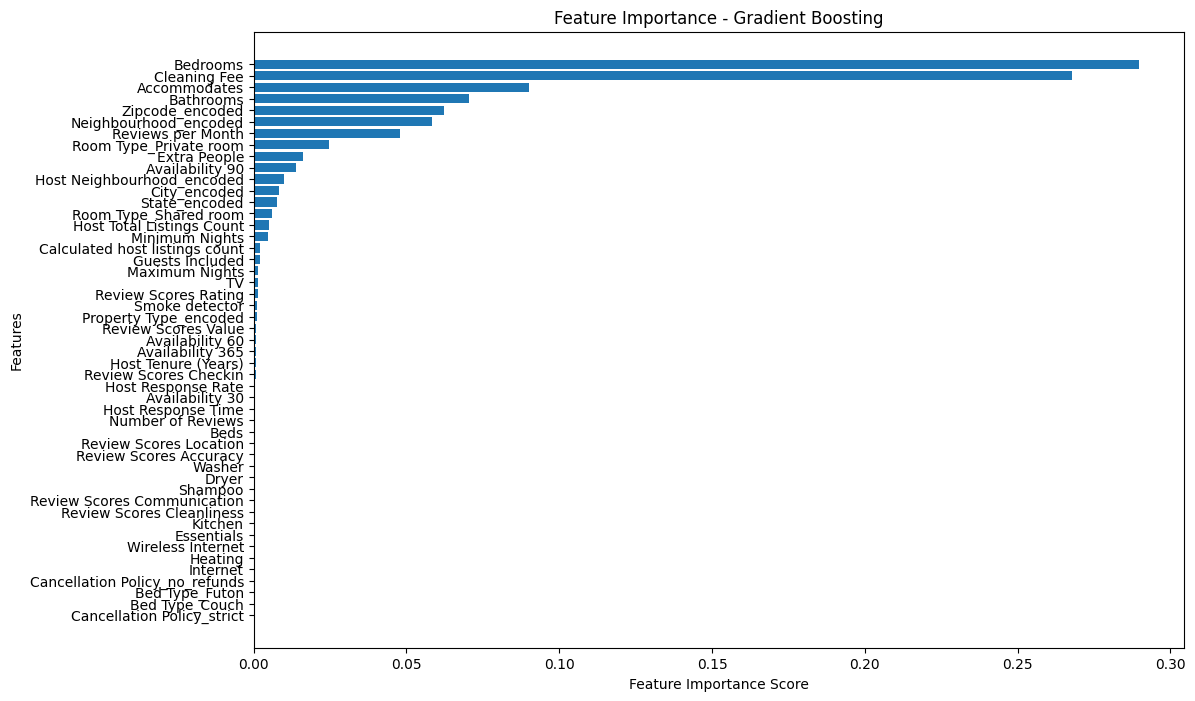

In [55]:
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd
import matplotlib.pyplot as plt

# Train model
model = GradientBoostingRegressor()
model.fit(X_train_gradient, y_train_gradient)

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train_gradient.columns,
    'Importance': model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance - Gradient Boosting")
plt.gca().invert_yaxis()  # Membalik sumbu agar fitur paling penting di atas
plt.show()


In [37]:
X_train_gradient.drop(["Cancellation Policy_super_strict_60", "Bed Type_Pull-out Sofa", "Bed Type_Real Bed", "Cancellation Policy_super_strict_30",
                       "Cancellation Policy_long_term", "Cancellation Policy_moderate", "Latitude", "Longitude"], axis=1, inplace=True)
X_test_gradient.drop(["Cancellation Policy_super_strict_60", "Bed Type_Pull-out Sofa", "Bed Type_Real Bed", "Cancellation Policy_super_strict_30",
                       "Cancellation Policy_long_term", "Cancellation Policy_moderate", "Latitude", "Longitude"], axis=1, inplace=True)

In [39]:
X_train_gradient.head()

,Host Response Time,Host Response Rate,Host Total Listings Count,Accommodates,Bathrooms,Bedrooms,Beds,Cleaning Fee,Guests Included,Extra People,Minimum Nights,Maximum Nights,Availability 30,Availability 60,Availability 90,Availability 365,Number of Reviews,Review Scores Rating,Review Scores Accuracy,Review Scores Cleanliness,Review Scores Checkin,Review Scores Communication,Review Scores Location,Review Scores Value,Calculated host listings count,Reviews per Month,Wireless Internet,Heating,Kitchen,Essentials,TV,Smoke detector,Shampoo,Internet,Washer,Dryer,Room Type_Private room,Room Type_Shared room,Bed Type_Couch,Bed Type_Futon,Cancellation Policy_no_refunds,Cancellation Policy_strict,Host Tenure (Years),City_encoded,State_encoded,Neighbourhood_encoded,Property Type_encoded,Host Neighbourhood_encoded,Zipcode_encoded
0,0,100.0,2,6.0,2,2,2,20.0,6.0,50.0,1.0,1125.0,26.0,56.0,86.0,361.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.00,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,9.301370,227.018003,227.778408,250.350369,143.422410,258.690773,259.607947
1,0,100.0,2,2.0,1,1,1,52.5,2.0,25.0,2.0,365.0,23.0,51.0,75.0,350.0,159.0,97.0,10.0,10.0,10.0,10.0,9.0,9.0,2.0,2.04,1,1,1,0,0,1,0,1,0,0,0,0,0,0,0,1,13.016438,186.921040,186.889256,162.564885,143.422410,156.253521,158.093151
2,2,100.0,3,1.0,1,1,1,10.0,1.0,0.0,2.0,1125.0,2.0,2.0,29.0,29.0,28.0,88.0,8.0,8.0,10.0,9.0,9.0,9.0,3.0,1.44,1,1,1,0,1,1,0,1,1,1,0,1,0,0,0,0,8.306849,113.220603,135.857808,96.916667,184.328342,131.033167,121.834264
3,0,100.0,1,1.0,1,1,1,16.0,1.0,0.0,1.0,1125.0,0.0,0.0,0.0,0.0,1.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,1.0,0.09,1,1,1,0,0,1,0,1,1,1,0,1,0,0,0,1,8.024658,135.547995,158.085619,94.933962,143.422410,88.084656,71.058442
4,2,90.0,1,2.0,1,0,1,52.5,1.0,0.0,1.0,1125.0,0.0,0.0,0.0,0.0,3.0,100.0,9.0,9.0,9.0,9.0,9.0,10.0,1.0,0.36,1,1,1,1,1,0,0,1,0,1,0,0,0,0,0,0,8.076712,172.336708,169.996422,75.882353,143.422410,94.020833,82.844828


In [56]:
model4 = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.04539391685174171,
    max_depth=7,
    subsample=0.903889391662847,
    min_samples_split=9,
    min_samples_leaf=7
)

# Melatih model
model4.fit(X_train_gradient, y_train_gradient)

# Prediksi
y_pred =  model4.predict(X_test_gradient)

# Evaluasi
mse4 = mean_squared_error(y_pred, y_test_gradient)
r4 = r2_score(y_test_gradient, y_pred)
mae4 = mean_absolute_error(y_test_gradient, y_pred)
rmse4 = np.sqrt(mean_squared_error(y_test_gradient, y_pred))

print(mse4)
print(r4)
print(mae4)
print(rmse4)

5719.474052136953
0.6848450676841982
42.39919573048699
75.6272044448091


In [23]:
def objective(trial):
    # Definisikan hyperparameter yang akan dituning
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
    }
    
    # Inisialisasi model dengan parameter yang diuji Optuna
    model = GradientBoostingRegressor(**params)
    
    # Evaluasi model dengan cross-validation
    mae = -np.mean(cross_val_score(model, X_train_gradient, y_train_gradient, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1))
    
    return mae  # Optuna akan mencari nilai MAE paling rendah


In [ ]:
import optuna
# Buat objek studi Optuna
study = optuna.create_study(direction='minimize')  # Karena kita ingin meminimalkan MAE

# Jalankan pencarian optimal dengan 50 percobaan
study.optimize(objective, n_trials=50, n_jobs=-1)

# Cetak hasil terbaik
print("Best MAE Score:", study.best_value)
print("Best Parameters:", study.best_params)


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-03-11 14:37:04,116] A new study created in memory with name: no-name-f36c5977-3e7a-4b43-b716-625d4d95c770
C:\Users\USER\AppData\Local\Temp\ipykernel_4816\1087447527.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.1),
[I 2025-03-11 14:39:11,254] Trial 0 finished with value: 46.89196444575973 and parameters: {'n_estimators': 100, 'learning_rate': 0.03492126672032319, 'max_depth': 6, 'min_samples_split': 17, 'min_samples_leaf': 1, 'subsample': 0.8826034589573926}. Best is trial 0 w

In [57]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Train model Gradient Boosting
model = GradientBoostingRegressor(
    n_estimators=800,
    learning_rate=0.033407427732671365,
    max_depth=9,
    subsample=0.8282421525424934,
    min_samples_split=17,
    min_samples_leaf=9
)
model.fit(X_train_gradient, y_train_gradient)

# Prediksi di training dan test set
y_train_pred = model.predict(X_train_gradient)
y_test_pred = model.predict(X_test_gradient)

# Hitung metrik evaluasi
train_mse = mean_squared_error(y_train_gradient, y_train_pred)
test_mse = mean_squared_error(y_test_gradient, y_test_pred)

train_rmse = train_mse ** 0.5
test_rmse = test_mse ** 0.5

train_r2 = r2_score(y_train_gradient, y_train_pred)
test_r2 = r2_score(y_test_gradient, y_test_pred)

# Cetak hasil evaluasi
print(f"Train RMSE: {train_rmse:.2f}, Test RMSE: {test_rmse:.2f}")
print(f"Train R² Score: {train_r2:.2f}, Test R² Score: {test_r2:.2f}")

# Cek overfitting/underfitting
if train_rmse < test_rmse * 0.7:
    print("⚠️ Overfitting terdeteksi! Model terlalu bagus di training set tapi buruk di test set.")
elif train_r2 < 0.7 and test_r2 < 0.7:
    print("⚠️ Underfitting terdeteksi! Model tidak cukup kompleks untuk menjelaskan data.")
else:
    print("✅ Model cukup baik, tidak overfitting atau underfitting.")


Train RMSE: 43.63, Test RMSE: 75.43
Train R² Score: 0.90, Test R² Score: 0.69
⚠️ Overfitting terdeteksi! Model terlalu bagus di training set tapi buruk di test set.


In [285]:
import pickle
from sklearn.ensemble import GradientBoostingRegressor

# Contoh model
model = GradientBoostingRegressor()
model.fit(X_train_gradient, y_train_gradient)

# Simpan model ke file .pkl
with open("gradient_boosting_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [249]:

model5 = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# Melatih model
model5.fit(X_train, y_train)

# Prediksi
y_pred = model5.predict(X_test)

# Evaluasi
mse5 = mean_squared_error(y_pred, y_test)
r5 = r2_score(y_test, y_pred)
mae5 = mean_absolute_error(y_test, y_pred)
rmse5 = np.sqrt(mean_squared_error(y_test, y_pred))

print(mse5)
print(r5)
print(mae5)
print(rmse5)

6257.724566364433
0.6551863433270297
45.12744560568254
79.10578086565123


In [250]:
model6 = LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# Melatih model
model6.fit(X_train, y_train)

# Prediksi
y_pred = model6.predict(X_test)

# Evaluasi
mse6 = mean_squared_error(y_pred, y_test)
r6 = r2_score(y_test, y_pred)
mae6 = mean_absolute_error(y_test, y_pred)
rmse6 = np.sqrt(mean_squared_error(y_test, y_pred))

print(mse6)
print(r6)
print(mae6)
print(rmse6)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003965 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3156
[LightGBM] [Info] Number of data points in the train set: 92299, number of used features: 49
[LightGBM] [Info] Start training from score 156.401835
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

# Feature Selection

In [286]:
df_encoded.head()

,Host Response Time,Host Response Rate,Host Total Listings Count,Latitude,Longitude,Accommodates,Bathrooms,Bedrooms,Beds,Price,Cleaning Fee,Guests Included,Extra People,Minimum Nights,Maximum Nights,Availability 30,Availability 60,Availability 90,Availability 365,Number of Reviews,Review Scores Rating,Review Scores Accuracy,Review Scores Cleanliness,Review Scores Checkin,Review Scores Communication,Review Scores Location,Review Scores Value,Calculated host listings count,Reviews per Month,Wireless Internet,Heating,Kitchen,Essentials,TV,Smoke detector,Shampoo,Internet,Washer,Dryer,Room Type_Private room,Room Type_Shared room,Bed Type_Couch,Bed Type_Futon,Bed Type_Pull-out Sofa,Bed Type_Real Bed,Cancellation Policy_long_term,Cancellation Policy_moderate,Cancellation Policy_no_refunds,Cancellation Policy_strict,Cancellation Policy_super_strict_30,Cancellation Policy_super_strict_60,Host Tenure (Years),City_encoded,State_encoded,Neighbourhood_encoded,Property Type_encoded,Host Neighbourhood_encoded,Zipcode_encoded
0,0,100.0,1,34.147756,-118.591338,2.0,1,1,1,150.0,25.0,1.0,0.0,1.0,1125.0,30.0,60.0,90.0,365.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.00,1,1,0,1,1,1,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,9.112329,135.512708,158.360986,132.938679,143.450689,126.274510,158.831933
1,2,100.0,1,34.164597,-118.600512,8.0,3,4,4,175.0,150.0,8.0,25.0,2.0,1125.0,9.0,19.0,28.0,28.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.00,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,7.915068,135.691049,157.853492,130.715000,175.244442,128.304167,164.504202
2,1,100.0,1,34.183150,-118.645064,3.0,1,1,1,79.0,55.0,1.0,25.0,2.0,26.0,30.0,60.0,90.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.00,1,1,1,1,1,1,0,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,7.109589,135.998982,157.764486,129.476415,125.789541,127.903614,116.821429
3,1,100.0,2,34.148594,-118.596684,2.0,1,1,1,175.0,100.0,1.0,0.0,2.0,5.0,12.0,42.0,72.0,72.0,2.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,2.0,0.16,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,0,0,0,1,0,0,12.726027,119.175000,158.085619,132.396135,177.731910,128.309524,157.686441
4,0,100.0,36,34.174245,-118.605876,6.0,2,3,4,450.0,200.0,6.0,50.0,3.0,1125.0,26.0,56.0,86.0,361.0,8.0,95.0,9.0,10.0,10.0,10.0,9.0,10.0,29.0,0.79,1,1,1,1,1,1,0,1,1,1,0,0,0,0,0,1,0,1,0,0,0,0,8.997260,135.512708,158.360986,132.938679,165.291346,192.628571,110.178571


In [207]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131856 entries, 0 to 131855
Data columns (total 58 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Host Response Time                   131856 non-null  int64  
 1   Accommodates                         131856 non-null  float64
 2   Bathrooms                            131856 non-null  int64  
 3   Bedrooms                             131856 non-null  int64  
 4   Beds                                 131856 non-null  int64  
 5   Price                                131856 non-null  float64
 6   Cleaning Fee                         131856 non-null  float64
 7   Guests Included                      131856 non-null  float64
 8   Extra People                         131856 non-null  float64
 9   Minimum Nights                       131856 non-null  float64
 10  Maximum Nights                       131856 non-null  float64
 11  Availability 

In [223]:
df_encoded.shape

(131856, 40)

In [216]:
df_encoded.drop(["Cancellation Policy_long_term", "Cancellation Policy_no_refunds", "Minimum Nights", "Host Response Rate Scaled", "Smoke detector",
                 "Host Response Time", "Day", "Month", "Year", "Wireless Internet", "Internet", "Essentials", "Cancellation Policy_super_strict_30",
                 "Availability 90", "Availability 365", "Availability 30", "Availability 60", "Shampoo"], axis=1, inplace=True)

In [ ]:
df_encoded.drop(["Cancellation Policy_super_strict_60", "",])

In [138]:
df_encoded['Zipcode'].nunique()

948

In [212]:
df_encoded['Price'].max()

np.float64(999.0)

In [251]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50)
    }
    
    model = lgb.LGBMRegressor(**params)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()
    return -score  # Minimalkan MSE

# Jalankan optimasi
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

# Hasil terbaik
print("Best Parameters:", study.best_params)
print("Best MSE:", study.best_value)


[I 2025-03-07 22:45:20,032] A new study created in memory with name: no-name-4e4aed87-18fc-45c3-8f3a-8ea2a86937f3
C:\Users\USER\AppData\Local\Temp\ipykernel_30176\4258103690.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003202 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3072
[LightGBM] [Info] Number of data points in the train set: 73839, number of used features: 49
[LightGBM] [Info] Start training from score 156.710072
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002815 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3126
[LightGBM] [Info] Number of data points in the train set: 73839, number of used features: 49
[LightGBM] [Info] Start training from score 156.302902
[LightGBM] [Warning] Fou

[I 2025-03-07 22:45:34,083] Trial 0 finished with value: 6234.834697921962 and parameters: {'num_leaves': 80, 'learning_rate': 0.18642512243345244, 'n_estimators': 900, 'max_depth': 45, 'min_child_samples': 16}. Best is trial 0 with value: 6234.834697921962.
C:\Users\USER\AppData\Local\Temp\ipykernel_30176\4258103690.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002674 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3072
[LightGBM] [Info] Number of data points in the train set: 73839, number of used features: 49
[LightGBM] [Info] Start training from score 156.710072
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002091 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3126
[LightGBM] [Info] Numb

[I 2025-03-07 22:45:46,499] Trial 1 finished with value: 5865.43012132183 and parameters: {'num_leaves': 62, 'learning_rate': 0.08347865629493036, 'n_estimators': 958, 'max_depth': 14, 'min_child_samples': 41}. Best is trial 1 with value: 5865.43012132183.
C:\Users\USER\AppData\Local\Temp\ipykernel_30176\4258103690.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),


...

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003139 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3072
[LightGBM] [Info] Number of data points in the train set: 73839, number of used features: 49
[LightGBM] [Info] Start training from score 156.710072
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003400 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3126
[LightGBM] [Info] Number of data points in the train set: 73839, number of used features: 49
[LightGBM] [Info] Start training from score 156.302902
[LightGBM] [Warning] Fou

[I 2025-03-07 22:54:30,013] Trial 48 finished with value: 5819.161928198545 and parameters: {'num_leaves': 71, 'learning_rate': 0.06875738542083627, 'n_estimators': 749, 'max_depth': 30, 'min_child_samples': 28}. Best is trial 7 with value: 5774.497304144248.
C:\Users\USER\AppData\Local\Temp\ipykernel_30176\4258103690.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003238 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3072
[LightGBM] [Info] Number of data points in the train set: 73839, number of used features: 49
[LightGBM] [Info] Start training from score 156.710072
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003856 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3126
[LightGBM] [Info] Number of data points in the train set: 73839, number of used features: 49
[LightGBM] [Info] Start training from score 156.302902
[LightGBM] [Warning] Fou

[I 2025-03-07 22:54:52,797] Trial 49 finished with value: 5792.786590623944 and parameters: {'num_leaves': 93, 'learning_rate': 0.05112066314215245, 'n_estimators': 851, 'max_depth': 27, 'min_child_samples': 38}. Best is trial 7 with value: 5774.497304144248.


Best Parameters: {'num_leaves': 92, 'learning_rate': 0.03307919278677949, 'n_estimators': 969, 'max_depth': 24, 'min_child_samples': 24}
Best MSE: 5774.497304144248


In [252]:
df_encoded.shape

(131856, 50)

C:\Users\USER\AppData\Local\Temp\ipykernel_30176\955909985.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pcc.index, y=pcc.values, palette="coolwarm")


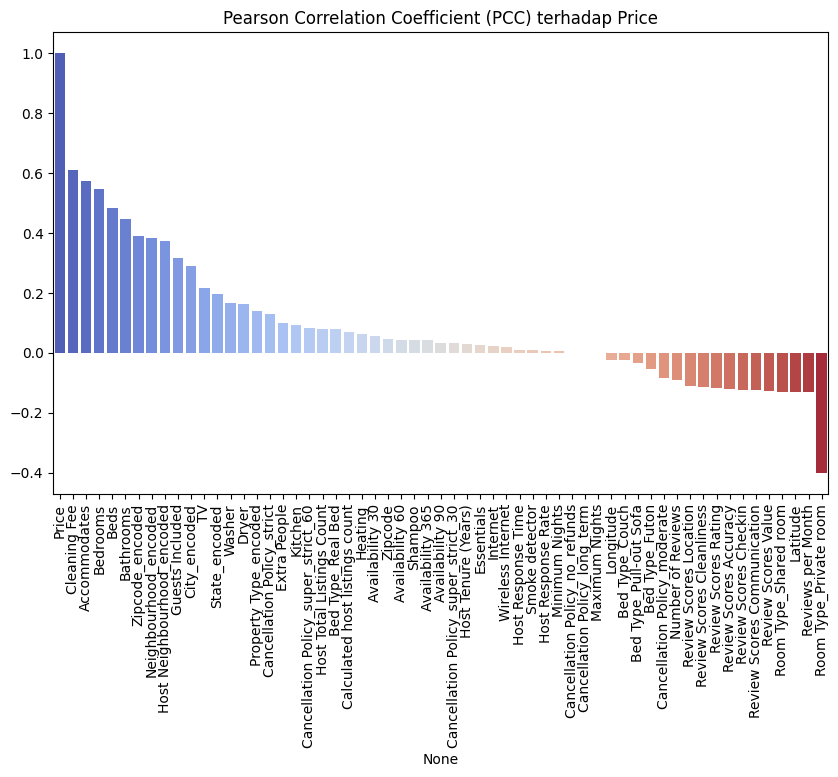

C:\Users\USER\AppData\Local\Temp\ipykernel_30176\955909985.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.index, y=mi_series.values, palette="coolwarm")


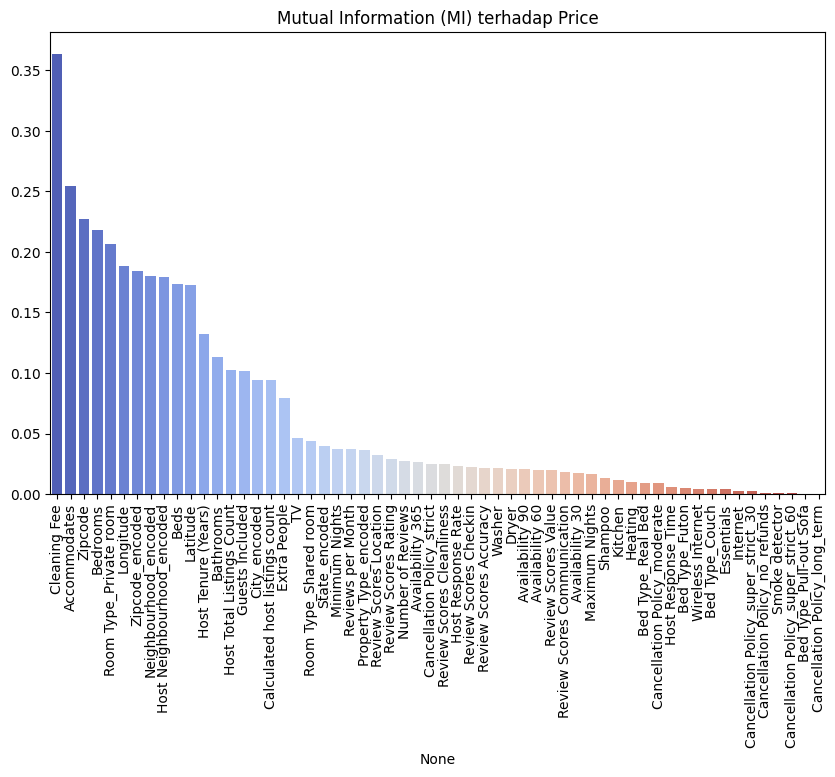

In [240]:
pcc = df_encoded.corr()["Price"].sort_values(ascending=False)

# Menghitung Mutual Information (MI)
X = df_encoded.drop(columns=["Price"])
y = df_encoded["Price"]
mi = mutual_info_regression(X, y)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

# Visualisasi PCC
plt.figure(figsize=(10, 6))
sns.barplot(x=pcc.index, y=pcc.values, palette="coolwarm")
plt.xticks(rotation=90)
plt.title("Pearson Correlation Coefficient (PCC) terhadap Price")
plt.show()

# Visualisasi MI
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_series.index, y=mi_series.values, palette="coolwarm")
plt.xticks(rotation=90)
plt.title("Mutual Information (MI) terhadap Price")
plt.show()

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006396 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3156
[LightGBM] [Info] Number of data points in the train set: 92299, number of used features: 49
[LightGBM] [Info] Start training from score 156.401835


<Figure size 3000x2200 with 0 Axes>

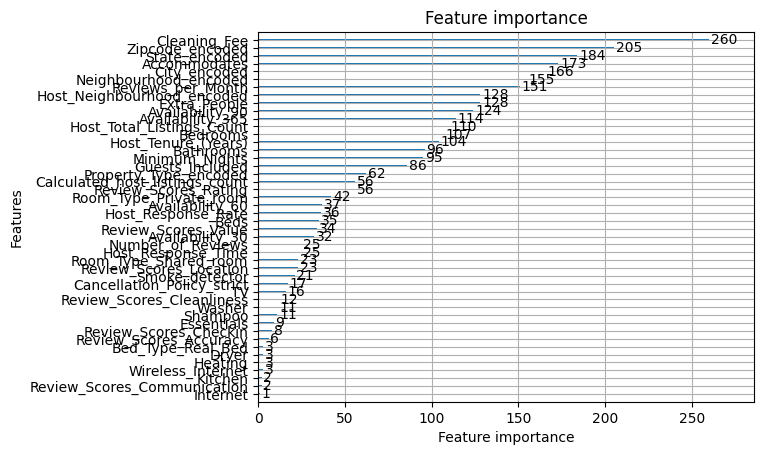

In [256]:
import lightgbm as lgb
import matplotlib.pyplot as plt

# Train model
plt.figure(figsize=(30, 22))
model = lgb.LGBMRegressor()
model.fit(X_train, y_train)

# Get feature importance
lgb.plot_importance(model)
plt.show()

In [257]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Get coefficients
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.coef_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

                           Feature  Importance
4                        Bathrooms   30.365033
5                         Bedrooms   26.495995
37                  Bed Type_Couch   14.970519
3                     Accommodates   10.611257
39          Bed Type_Pull-out Sofa   10.017266
30                  Smoke detector    8.382941
29                              TV    5.805187
38                  Bed Type_Futon    5.576295
40               Bed Type_Real Bed    5.336151
26                         Heating    4.222951
32                        Internet    2.544711
33                          Washer    1.923616
31                         Shampoo    1.875992
16            Review Scores Rating    1.066688
25               Wireless Internet    0.781440
11                 Availability 30    0.737513
18       Review Scores Cleanliness    0.701591
7                     Cleaning Fee    0.622476
21          Review Scores Location    0.517688
48                 Zipcode_encoded    0.365410
42           

In [139]:
df_encoded.describe()

,Host Response Time,Host Response Rate,Host Total Listings Count,Zipcode,Latitude,Longitude,Accommodates,Bathrooms,Bedrooms,Beds,Price,Cleaning Fee,Guests Included,Extra People,Minimum Nights,Maximum Nights,Availability 30,Availability 60,Availability 90,Availability 365,Number of Reviews,Review Scores Rating,Review Scores Accuracy,Review Scores Cleanliness,Review Scores Checkin,Review Scores Communication,Review Scores Location,Review Scores Value,Calculated host listings count,Reviews per Month,Wireless Internet,Heating,Kitchen,Essentials,TV,Smoke detector,Shampoo,Internet,Washer,Dryer,Room Type_Private room,Room Type_Shared room,Bed Type_Couch,Bed Type_Futon,Bed Type_Pull-out Sofa,Bed Type_Real Bed,Cancellation Policy_long_term,Cancellation Policy_moderate,Cancellation Policy_no_refunds,Cancellation Policy_strict,Cancellation Policy_super_strict_30,Cancellation Policy_super_strict_60,City_encoded,State_encoded,Neighbourhood_encoded,Property Type_encoded,Host Neighbourhood_encoded,Zipcode_encoded,Year,Month,Day
count,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,1.318560e+05,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000,131856.000000
mean,0.520014,95.237448,8.220597,56102.375000,37.573955,-96.827997,3.348873,1.221605,1.326037,1.792986,155.937265,60.548898,1.667600,12.753117,3.269567,1.608103e+05,10.607473,24.598046,40.728461,168.296141,20.216926,73.228586,7.481685,7.316137,7.603810,7.610496,7.413383,7.349389,3.367552,1.351934,0.964401,0.916993,0.916818,0.855964,0.742393,0.698444,0.687894,0.970331,0.637703,0.646963,0.387332,0.032194,0.003602,0.010989,0.007827,0.970900,0.000008,0.261209,0.000038,0.422901,0.001668,0.001532,155.961360,155.937296,155.931996,155.937133,155.939636,155.919661,2013.919078,6.460844,15.603901
std,0.800133,14.964406,51.939855,37435.513283,4.382431,20.662164,2.248807,0.560616,0.882054,1.327223,136.639945,49.601246,1.388059,22.057511,8.543928,1.786193e+07,11.030055,22.404844,33.967752,141.259351,37.130899,39.780915,4.061118,4.008249,4.105929,4.108541,4.025351,4.000748,9.618139,1.949087,0.185290,0.275894,0.276158,0.351127,0.437318,0.458935,0.463354,0.169672,0.480666,0.477916,0.487142,0.176516,0.059912,0.104252,0.088122,0.168087,0.002754,0.439295,0.006158,0.494022,0.040813,0.039111,40.446311,26.764866,54.755378,19.307390,54.335979,55.069134,1.760777,3.361575,8.800486
min,0.000000,0.000000,0.000000,2108.000000,29.898266,-122.833981,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.750000,107.246909,25.000000,46.425926,22.666667,14.750000,2008.000000,1.000000,1.000000
25%,0.000000,100.000000,1.000000,11216.000000,34.050096,-118.351888,2.000000,1.000000,1.000000,1.000000,75.000000,25.000000,1.000000,0.000000,1.000000,3.000000e+01,0.000000,0.000000,1.000000,18.000000,1.000000,80.000000,8.000000,7.000000,9.000000,9.000000,8.000000,8.000000,1.000000,0.070000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,

In [181]:
scaler = MinMaxScaler()
df_encoded["Host Response Rate Scaled"] = scaler.fit_transform(df_encoded[["Host Response Rate"]])

In [182]:
df_encoded["Host Response Rate Scaled"].unique()

array([1.  , 0.88, 0.92, 0.9 , 0.75, 0.79, 0.7 , 0.98, 0.99, 0.97, 0.94,
       0.85, 0.91, 0.96, 0.82, 0.67, 0.83, 0.33, 0.89, 0.95, 0.93, 0.  ,
       0.5 , 0.8 , 0.87, 0.86, 0.76, 0.63, 0.81, 0.57, 0.78, 0.84, 0.6 ,
       0.11, 0.25, 0.4 , 0.56, 0.73, 0.58, 0.2 , 0.71, 0.54, 0.36, 0.72,
       0.66, 0.3 , 0.77, 0.53, 0.61, 0.44, 0.29, 0.42, 0.14, 0.43, 0.38,
       0.64, 0.1 , 0.31, 0.55, 0.13, 0.69, 0.59, 0.65, 0.68, 0.74, 0.46,
       0.17, 0.47, 0.03, 0.18, 0.07, 0.52, 0.22, 0.48, 0.27, 0.62, 0.05,
       0.32, 0.23, 0.09, 0.41, 0.49, 0.15, 0.35, 0.04, 0.39, 0.51, 0.24,
       0.19, 0.45, 0.34, 0.08, 0.28, 0.06])

In [183]:
df_encoded.drop("Host Response Rate", axis=1, inplace=True)

In [188]:
df_encoded["Host Total Listings Count"].value_counts()

Host Total Listings Count
1       78090
2       21256
3        9050
4        4902
5        3021
6        2166
7        1536
8        1335
9         997
11        714
10        699
12        535
16        359
21        328
15        311
14        296
18        278
20        264
27        263
25        256
13        255
24        227
17        184
22        178
34        176
19        171
23        162
749       136
30        130
0         124
26        119
36        116
33        113
28        100
35         98
47         92
53         90
372        83
60         83
609        81
69         80
558        79
479        78
879        78
162        74
48         69
187        69
29         65
307        64
178        63
50         62
313        61
37         58
119        58
363        56
38         55
54         51
62         51
52         51
82         51
43         48
45         44
341        44
472        43
80         42
40         41
169        39
56         39
173        39
339     

In [189]:
df_encoded["Host Total Listings Count Log"] = np.log1p(df_encoded["Host Total Listings Count"])

In [191]:
df_encoded.drop("Host Total Listings Count", axis=1, inplace=True)

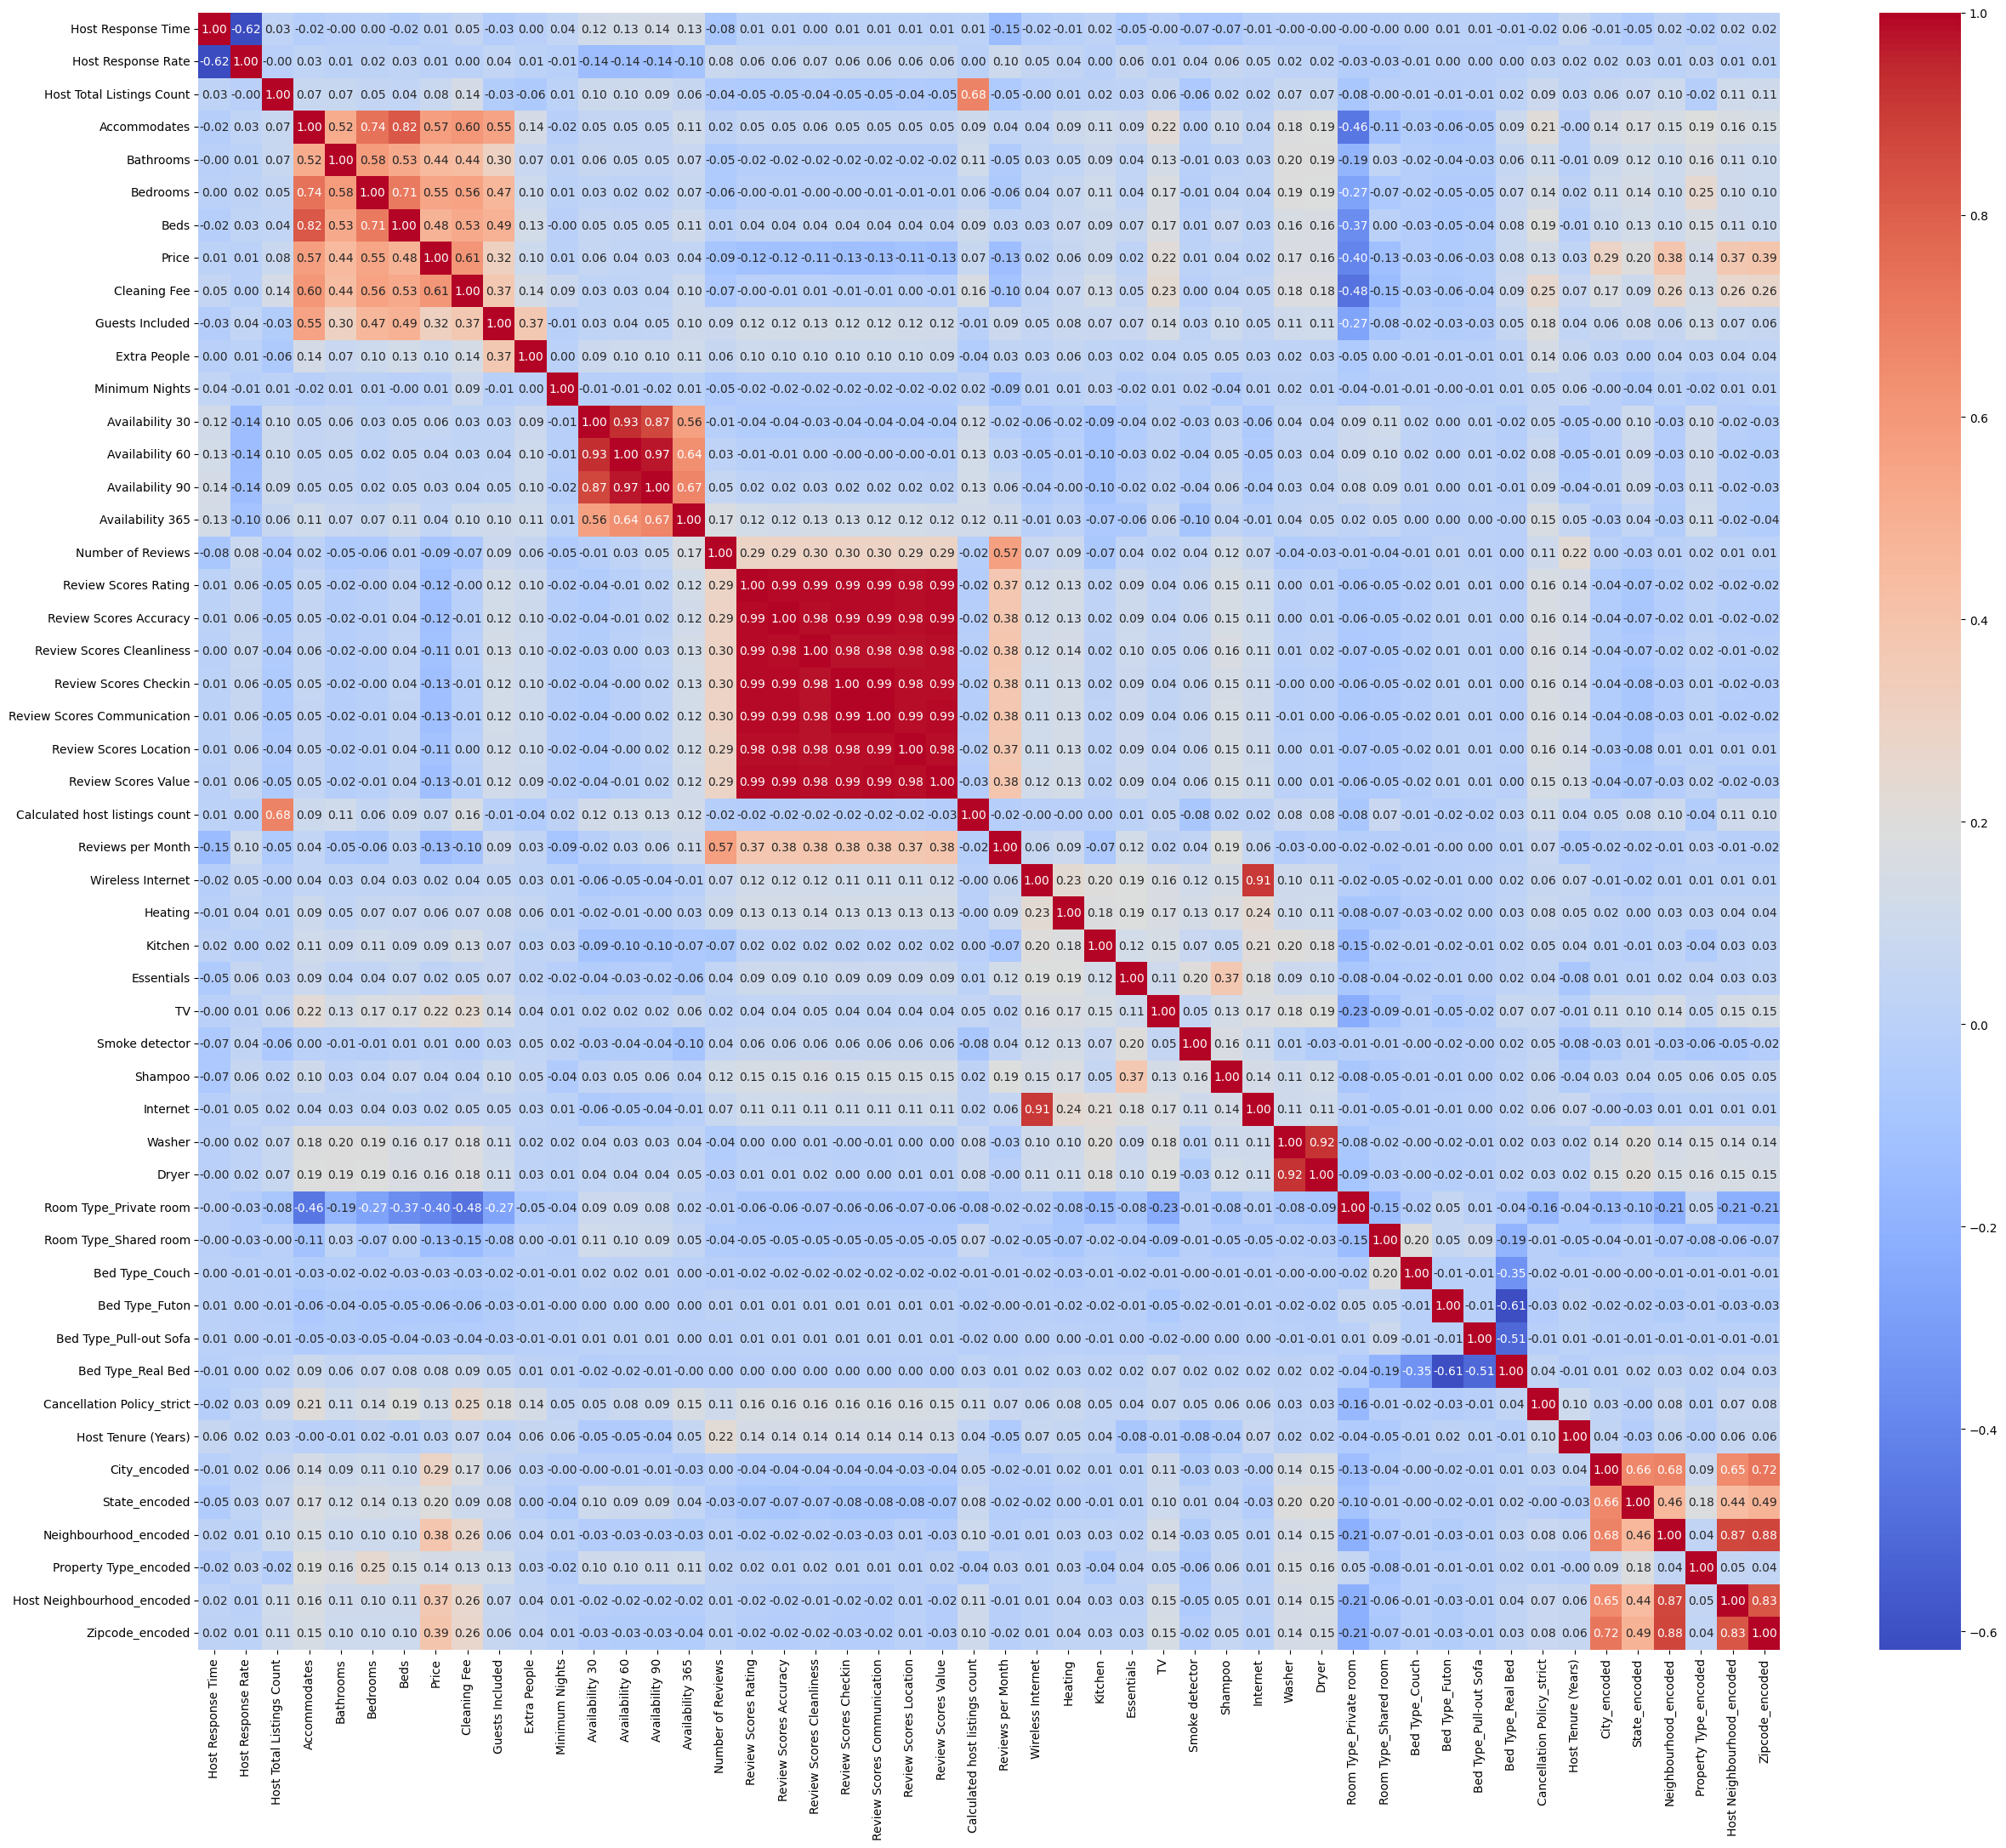

In [253]:
corr_matrix = df_encoded.corr()
plt.figure(figsize=(30,25))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm",fmt=".2f", annot_kws={"size": 10})
plt.show()